In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                             roc_curve, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')
print("✅ Imports done")

✅ Imports done


In [2]:
df = pd.read_csv('./df_final.csv', parse_dates=['order_purchase_timestamp'])

# Build customer level features
analysis_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

features = df.groupby('customer_unique_id').agg(
    recency        =('order_purchase_timestamp', lambda x: (analysis_date - x.max()).days),
    frequency      =('order_id',                'nunique'),
    monetary       =('revenue',                 'sum'),
    avg_profit     =('profit',                  'mean'),
    avg_freight    =('freight_value',           'mean'),
    avg_price      =('price',                   'mean'),
    total_items    =('order_item_id',           'sum'),
    avg_installments=('payment_installments',   'mean'),
    days_active    =('order_purchase_timestamp',
                     lambda x: (x.max() - x.min()).days + 1)
).reset_index()

# Target — churned = bought only once
features['churned'] = (features['frequency'] == 1).astype(int)

print(f"✅ Features built: {features.shape}")
print(f"\nChurn Rate: {features['churned'].mean():.1%}")
print(features['churned'].value_counts())

✅ Features built: (93335, 11)

Churn Rate: 97.0%
churned
1    90535
0     2800
Name: count, dtype: int64


In [3]:
feature_cols = [
    'recency', 'frequency', 'monetary',
    'avg_profit', 'avg_freight', 'avg_price',
    'total_items', 'avg_installments', 'days_active'
]

X = features[feature_cols].fillna(0)
y = features['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler       = StandardScaler()
X_train_sc   = scaler.fit_transform(X_train)
X_test_sc    = scaler.transform(X_test)

print(f"✅ Train: {X_train.shape} | Test: {X_test.shape}")

✅ Train: (74668, 9) | Test: (18667, 9)


In [4]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:,1]
    auc    = roc_auc_score(y_test, y_prob)
    results[name] = {'model': model, 'auc': auc,
                     'y_pred': y_pred, 'y_prob': y_prob}
    print(f"\n{'='*45}")
    print(f"{name} | AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred))


Logistic Regression | AUC: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       560
           1       1.00      1.00      1.00     18107

    accuracy                           1.00     18667
   macro avg       1.00      1.00      1.00     18667
weighted avg       1.00      1.00      1.00     18667


Random Forest | AUC: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       560
           1       1.00      1.00      1.00     18107

    accuracy                           1.00     18667
   macro avg       1.00      1.00      1.00     18667
weighted avg       1.00      1.00      1.00     18667


Gradient Boosting | AUC: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       560
           1       1.00      1.00      1.00     18107

    accuracy                           1.00     18667
   macro avg       1.00      1.

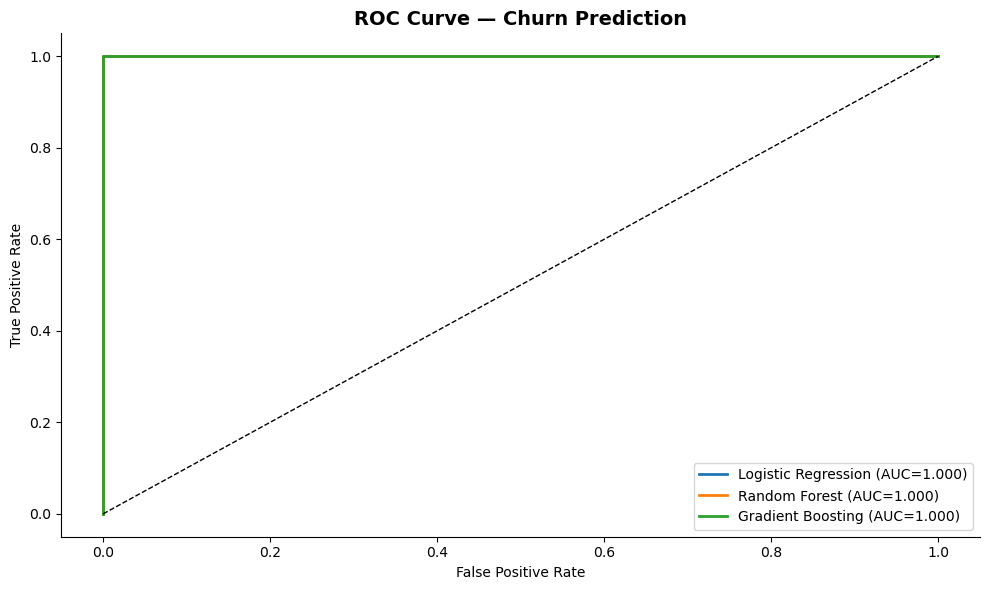

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, linewidth=2,
            label=f"{name} (AUC={res['auc']:.3f})")

ax.plot([0,1],[0,1], 'k--', linewidth=1)
ax.set_title('ROC Curve — Churn Prediction',
             fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

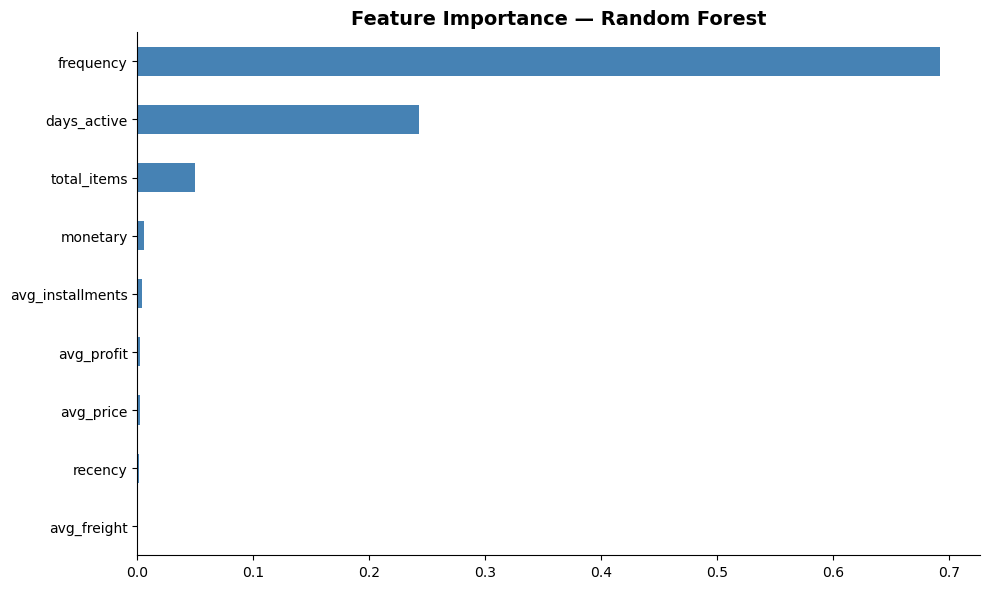

In [6]:
best_model = results['Random Forest']['model']
importances = pd.Series(
    best_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
importances.plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Feature Importance — Random Forest',
             fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

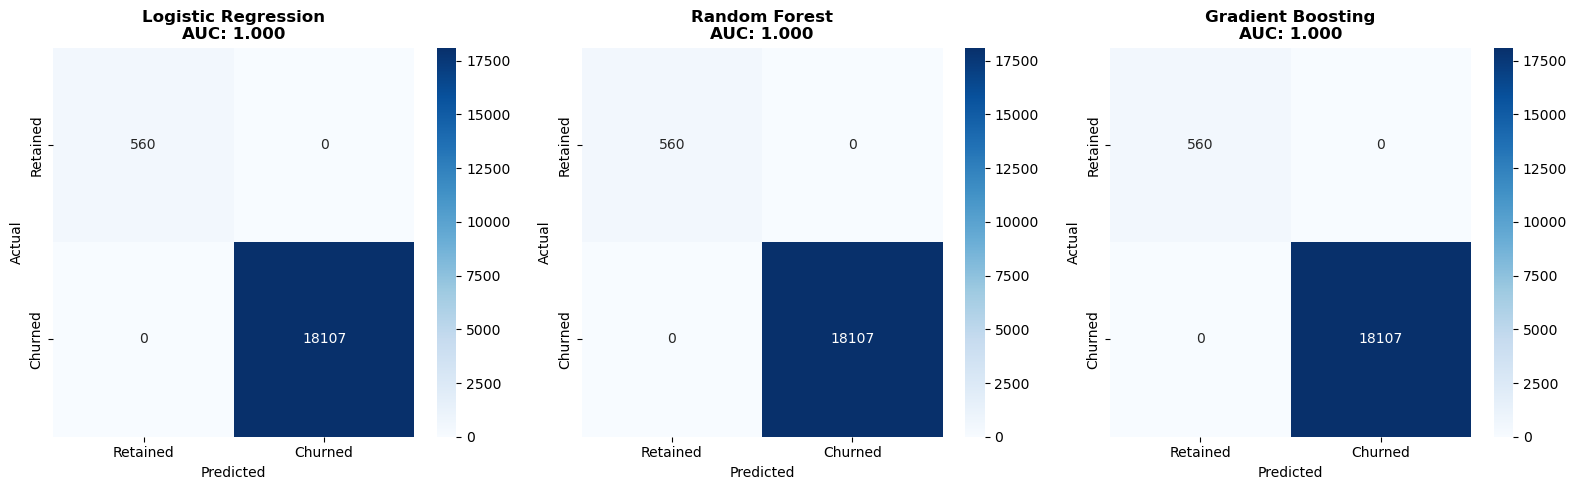

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d',
                cmap='Blues', ax=axes[i],
                xticklabels=['Retained','Churned'],
                yticklabels=['Retained','Churned'])
    axes[i].set_title(f'{name}\nAUC: {res["auc"]:.3f}',
                      fontweight='bold')
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

In [8]:
features['churn_probability'] = results['Random Forest']['model'].predict_proba(
    scaler.transform(X.fillna(0))
)[:,1]

features['churn_risk'] = pd.cut(
    features['churn_probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

features.to_csv('./churn_predictions.csv', index=False)

print("✅ Predictions saved!")
print(features['churn_risk'].value_counts())

✅ Predictions saved!
churn_risk
High Risk      90535
Low Risk         237
Medium Risk        0
Name: count, dtype: int64
